In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train = pd.read_csv('/content/drive/MyDrive/load_datas/comment-category-prediction-challenge/train.csv')

In [ ]:
train.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [ ]:
# train.iloc[:, 2:5]
train["total_emoticons"] = train.iloc[:, 2:5].sum(axis = 1)
train.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label,total_emoticons
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2,0
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0,0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2,0
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2,0


In [ ]:
# train.loc[(train["label"]==3), "comment"].len().median() #only works when using .str
train.loc[(train["label"]==3), "comment"].str.len().median()

128.0

In [ ]:
tokens = train["comment"].str.lower().str.split().explode().nunique()
tokens

#.explode() - with this you can perform operation on entire column at once


425413

## Date Time

In [ ]:
train["created_date"] = pd.to_datetime(train["created_date"])
train["day"] = train["created_date"].dt.day
train["month"] = train["created_date"].dt.month
train["year"] = train["created_date"].dt.year
train

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label,total_emoticons,day,month,year
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2,0,18,1,2024
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0,0,24,3,2024
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2,2,24,4,2024
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2,0,28,5,2023
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2,0,9,9,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197995,2023-02-04 10:39:30.581185+00:00,39,0,0,0,2,0,0,4,NaN,NaN,NaN,False,Why save people who are bent on self-destructi...,0,0,4,2,2023
197996,2023-11-01 17:16:51.337370+00:00,72,0,0,0,1,0,0,10,NaN,NaN,NaN,False,Trudeau is not only undemocratic but also innu...,2,0,1,11,2023
197997,2024-03-09 15:46:22.542539+00:00,72,0,0,0,0,0,0,10,NaN,NaN,NaN,False,block all exports no humanitarian relief and a...,3,0,9,3,2024
197998,2023-08-07 17:23:40.163756+00:00,72,0,1,1,5,7,4,10,black,none,none,False,really black kids seeing that is better than g...,1,2,7,8,2023


In [ ]:
train['gender'].value_counts(normalize = True, dropna = False)*100
# train['gender'].value_counts()

,proportion
gender,
NaN,73.445960
none,18.263131
female,4.059091
male,3.812626
transgender,0.314141
other,0.105051


In [ ]:
train.isna().sum()
train.isna().sum().sum()

np.int64(436270)

In [ ]:
# Drops
df = train.copy(deep = True) #copies recurssivly through the dataset

In [ ]:
df = df.dropna(inplace=True, axis=1)

In [ ]:
# df.isna().sum()


In [ ]:
df['age'] = np.random.randint(5, 75, size=len(df))
df['age'].value_counts()

TypeError: object of type 'NoneType' has no len()

In [ ]:
ages = ["Young", "Teen","Adult", "Oldies" ]

In [ ]:
df['age'] = pd.qcut(df['age'], q = 4, labels = ages)

TypeError: 'NoneType' object is not subscriptable

In [ ]:
def grouping(age):
  if age<12:
    return "Young"
  elif 12<=age<18:
    return "Teen"
  elif 18<=age<50:
    return "Adult"
  elif age>50:
    return "Oldies"
  elif age == np.nan:
    return np.nan
  else:
    return

In [ ]:

df.head()

AttributeError: 'NoneType' object has no attribute 'head'

In [ ]:
df["age"].dtype

TypeError: 'NoneType' object is not subscriptable

In [ ]:
# df["age"] = df['age'].apply(grouping) #so the applies the values and passes thorugh the function

In [ ]:
df['age'].value_counts(dropna = False)

TypeError: 'NoneType' object is not subscriptable

In [ ]:
df['comment'].value_counts().head(10)

TypeError: 'NoneType' object is not subscriptable

In [ ]:
comment = {
    "Exactly": "Short",
    "Yes": "Affermative",
    "No": "Not Sure",
    "lier": "Evil Doer",
    "else": "Too long vals"
}

In [ ]:
df['comment'] = df['comment'].map(comment)
df['comment'].value_counts()


TypeError: 'NoneType' object is not subscriptable

In [ ]:
df

In [ ]:
df_copy = df.copy(deep= True)


AttributeError: 'NoneType' object has no attribute 'copy'

In [ ]:
df_copy.rename(columns = {"age": "Ages"},inplace  =True)

NameError: name 'df_copy' is not defined

In [ ]:
df_copy.head()

NameError: name 'df_copy' is not defined

In [ ]:
# filtering
df_copy.columns.get_loc("Ages")

NameError: name 'df_copy' is not defined

## Use of Replace:
```python
df.replace({'male':0, 'female':1}, inplace=True)
or 
df.replace(to_replace=['male','female'], value=[0,1], inplace=True)
```

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from numpy._core import numeric
df_ages = df.groupby(["year"], dropna=False)
df_ages['day'].mean().plot()

AttributeError: 'NoneType' object has no attribute 'groupby'

In [ ]:
df

In [ ]:
df[["emoticon_1", "emoticon_2" ,"emoticon_3"]].agg(["min", "max","median", "std",'var'])

TypeError: 'NoneType' object is not subscriptable

In [ ]:
df[["emoticon_1", "emoticon_2" ,"emoticon_3"]].agg(["max", "min"])

TypeError: 'NoneType' object is not subscriptable

In [ ]:
df = pd.DataFrame(np.random.random(size=(5, 10)), columns=list('abcdefghij'))
display(df.sum(axis=0).idxmin()) #this is how to find the column with the minimum sum

'f'

## **row-wise indexing + missing-value logic question**

In [ ]:
# so baically you've to start with each row and return the name of colm which's 3rd to have NaN
def iter3(lst, n=3):
    cnt = 0
    for col, val in lst.items():
        if pd.isna(val):
            cnt+=1
            if cnt == n:
                return col


# iter3((df.iloc[0,:][1]), 3)
df.apply(iter3,axis = 1)

# Another and better approach
df.isna().apply(lambda row: row[row].index[2], axis=1)

IndexError: index 2 is out of bounds for axis 0 with size 0

In [ ]:
# If you want to access individual elements - Just remeber it's all dictionary
# example:
nan = np.nan

data = [[0.04,  nan,  nan, 0.25,  nan, 0.43, 0.71, 0.51,  nan,  nan],
        [ nan,  nan,  nan, 0.04, 0.76,  nan,  nan, 0.67, 0.76, 0.16],
        [ nan,  nan, 0.5 ,  nan, 0.31, 0.4 ,  nan,  nan, 0.24, 0.01],
        [0.49,  nan,  nan, 0.62, 0.73, 0.26, 0.85,  nan,  nan,  nan],
        [ nan,  nan, 0.41,  nan, 0.05,  nan, 0.61,  nan, 0.48, 0.68]]

columns = list('abcdefghij')

df = pd.DataFrame(data, columns=columns)
display(df)

for i in df.iloc[0,:].items():
    print(i)

,a,b,c,d,e,f,g,h,i,j
0,0.04,NaN,NaN,0.25,NaN,0.43,0.71,0.51,NaN,NaN
1,NaN,NaN,NaN,0.04,0.76,NaN,NaN,0.67,0.76,0.16
2,NaN,NaN,0.50,NaN,0.31,0.40,NaN,NaN,0.24,0.01
3,0.49,NaN,NaN,0.62,0.73,0.26,0.85,NaN,NaN,NaN
4,NaN,NaN,0.41,NaN,0.05,NaN,0.61,NaN,0.48,0.68


('a', 0.04)
('b', nan)
('c', nan)
('d', 0.25)
('e', nan)
('f', 0.43)
('g', 0.71)
('h', 0.51)
('i', nan)
('j', nan)


## Understanding Lambda

For each *group*, find the sum of the three greatest values. You should end up with the answer as follows:
```
grps
a    409
b    156
c    345
```

In [ ]:
df = pd.DataFrame({'grps': list('aaabbcaabcccbbc'),
                'vals': [12,345,3,1,45,14,4,52,54,23,235,21,57,3,87]})

# display(df.sort_values(by = 'vals',ascending=False))
# display(df.groupby('grps', sort=True).head(3))
# to find the sum of the 3 largest elements on the groups

# Run this to visualise
display(df.groupby("grps")["vals"].apply(lambda x: print((x.sort_values(ascending=False)[:3]))))

1    345
7     52
0     12
Name: a, dtype: int64
12    57
8     54
4     45
Name: b, dtype: int64
10    235
14     87
9      23
Name: c, dtype: int64


,vals
grps,
a,None
b,None
c,None


In [ ]:
# The same thing can be implemented using this
display(df.groupby("grps")["vals"].apply(lambda x: x.nlargest(3).sum())) #nsmallest too

,vals
grps,
a,409
b,156
c,345


### use of cumsum for diff things:
```python
df = pd.DataFrame({'X': [7, 2, 0, 3, 4, 2, 5, 0, 3, 4]})

```

In [ ]:
df = pd.DataFrame({'X': [7, 2, 0, 3, 4, 2, 5, 0, 3, 4]})
df

# brute:
cnt = 0
for i in df.values!=0:
    if i:
        cnt+=1
    else:
        cnt= 0
    print(cnt)

mask = df["X"] !=0
# print((~mask).cumsum())
# efficient way:
print(mask.groupby((~mask).cumsum()).cumsum())
# let's use this to solve the prev question

display((df["X"]!=0).groupby((df["X"]==0).cumsum()).cumsum())


1
2
0
1
2
3
4
0
1
2
0    1
1    2
2    0
3    1
4    2
5    3
6    4
7    0
8    1
9    2
Name: X, dtype: int64


,X
0,1
1,2
2,0
3,1
4,2
5,3
6,4
7,0
8,1
9,2


### Using Stack and Unstack - *flatten the DataFrame*
"if you think: “Do I need to look across the whole table at once?” then yep use stack or unstack."

    stack() → wide ➜ long : “Take columns and push them into the row index.”
    unstack() → long ➜ wide : index level → becomes columns: “Take an index level and spread it into columns.”

```python
df = pd.DataFrame(np.random.RandomState(30).randint(1, 101, size=(8, 8)))
data = df.unstack().sort_values(ascending=False).head(3)
data.index.tolist()
```

1. df.stack()
    turns the df into a row and gives you a multi-index of (row, col) for each value.


In [ ]:
#@title Assigning values using .loc

In [ ]:
df = pd.DataFrame({"vals": np.random.RandomState(31).randint(-30, 30, size=15),
                "grps": np.random.RandomState(31).choice(["A", "B"], 15)})
# say we want to change the negatives with their group means.

In [ ]:
meanA, meanB = round(df.groupby('grps')['vals'].mean(), 2)

In [ ]:
# wrong way:
# raw wrong method - because there's a size mismatch when trying to group A and B separetly..
df["patched_vals"] = df[df["grps"]=="A"]["vals"].apply(lambda x: meanA if x<0 else x)
#here, size < index size -> thus rest indes will get replaced with NaN

In [ ]:
# correct way: Assign the defaults first then make the changes using .loc
df["patched_vals"] = df["vals"].astype('float64')
df.loc[(df["grps"]=="A") & (df["vals"]<0), "patched_vals"] = meanA
df.loc[(df["grps"]=="B") & (df["vals"]<0), "patched_vals"] = meanB

## Use of Where:


`original.where(condition, replacement)`

In [ ]:
# even better interview level way:
# efficent in best way: compute once → broadcast → mask replace
means = df.groupby("grps")["vals"].transform("mean")
df["patched_vals"] = df["vals"].where(df["vals"]>=0, means)
df

,vals,grps,patched_vals
0,-12,A,-0.333333
1,-7,B,6.333333
2,-14,A,-0.333333
3,4,A,4.000000
4,-7,A,-0.333333
5,28,B,28.000000
6,-2,A,-0.333333
7,-1,A,-0.333333
8,8,A,8.000000
9,-2,B,6.333333


## The use of Resample in pandas:
The df.resample() method in pandas is primarily used for frequency conversion and resampling of time series data. It is a powerful tool for grouping time-indexed data into different time bins (e.g., from daily to monthly) and then applying an aggregation function (like mean(), sum(), etc.) to those bins.

This method is particularly useful when you have time series data and want to analyze it at different time intervals. For example, you can resample daily data into monthly data by taking the mean of each month's values.

## The use of Resample in pandas:
The df.resample() method in pandas is primarily used for frequency conversion and resampling of time series data. It is a powerful tool for grouping time-indexed data into different time bins (e.g., from daily to monthly) and then applying an aggregation function (like mean(), sum(), etc.) to those bins.

This method is particularly useful when you have time series data and want to analyze it at different time intervals. For example, you can resample daily data into monthly data by taking the mean of each month's values.

basic example:
```python
import pandas as pd
import numpy as np
# Create a time series data
date_range = pd.date_range(start='2020-01-01', end='2020-12-31', freq='D')
data = np.random.rand(len(date_range))
df = pd.DataFrame(data, index=date_range, columns=['Value'])
# Resample the data to monthly frequency and calculate the mean
monthly_mean = df.resample('M').mean()
print(monthly_mean)
```In this example, we create a daily time series data for the year 2020 and then resample it to monthly frequency by calculating the mean of the values for each month. The resulting DataFrame will contain the average value for each month in the year 2020.

In [ ]:
 data = pd.read_csv('/content/drive/MyDrive/load_datas/Bitcoin Historical Data.csv')

In [ ]:
# cleaning and preprocessing
data["Date"] = pd.to_datetime(data["Date"])
data  = data.set_index("Date") #for resampleing the data should be index
# converting the str to float for later analysis
data[["Price", "Open", "High", "Low"]] = data[["Price", "Open", "High", "Low"]].apply(lambda s: [float(x.replace(",", "")) for x in s])

data.resample("MS")["Price"].mean()

In [ ]:
data.resample("W")["Price"].mean().plot() #year
data.resample("YS")["Price"].mean().plot() #year
l

## About the use of sns.barplot:


```python
plt.figure(figsize=(15,6))
# sns.barplot(x = "Aggregate rating", y= "Rating Count", data= rating_df, width=0.5, hue= "Rating color")
sns.barplot(x = "Aggregate rating", y= "Rating Count", data= rating_df, width=0.5,hue= "Rating color", palette=['Grey', 'Red', 'Orange', 'Yellow', 'Green', 'Blue'], dodge= False) #using of hue is essential else you can't map the color with the plot for each group of data - like only for 0.0 -> should the bar have color White or grey
# The hue affirms the above comment and the palette help in custom coloring.
```

## How to change a data name from a column to something else across the dataset:
```python
# since Dark Green is not reconsied let's chage it's color to something diffrent
df['Rating color'] = df['Rating color'].replace('Dark Green', 'Blue')
df['Rating color'].unique().tolist()

# this is how you replace a group data from a column across the dataset with hindering anyhitng else/
```

## How to fidn the weightage of a group data in a column:
```python
# df[['Rating count', 'Rating color']].groupby('Rating color').count()
total = rating_df['Rating Count'].sum()
color_weitage = rating_df.groupby('Rating color')['Rating Count'].sum().reset_index() #.rest_index is essential as to reset the dataset view for any set-dataset you create, else you can understad by remove it the clear diffrence.

color_weitage['Weitage'] = (color_weitage['Rating Count']/total)*100
color_weitage = color_weitage.sort_values(by = 'Weitage', ascending=False)
orderd_color = color_weitage['Rating color'].tolist()

# ploting the weitage of the group data in a column:
plt.pie( x=color_weitage['Weitage'], labels = color_weitage['Rating color'], autopct='%1.1f%%', colors=orderd_color) #make sure that the order matchs that of the indexs
plt.show()
display(color_weitage)  
```
 
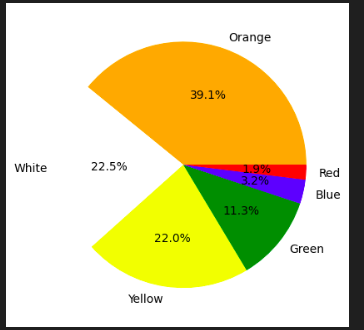

Function,Best Use Case,Logic
sns.countplot,"Raw data (e.g., a list of 5,000 ""Male"" or ""Female"" strings).",It does the math for you.
sns.barplot,"Summarized data (e.g., you already have the totals in a table).",It just draws what you tell it to.

```python
# also can plot like this to find realtions
plt.figure(figsize=(12,6))
# sns.countplot(x = 'Rating Count', data = rating_df, palette=orderd_color)
sns.barplot(x='Rating text', y='Rating Count', data=rating_df, palette='viridis')
```
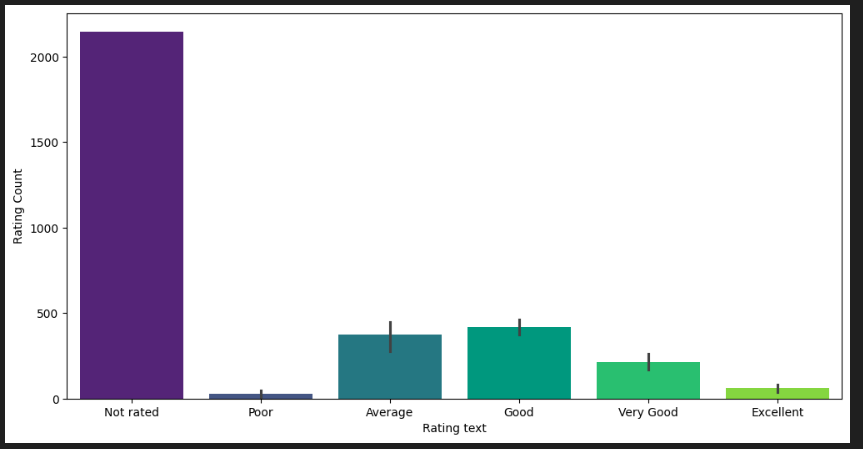

## If you want to sum or perform oprations on many cols at once:
```python
noramlly: df['emoji_counts'] = df['emoticon_1']+df['emoticon_2']+df['emoticon_3']
                                or
df['emoticon_count'] = df[['emoticon_1','emoticon_2','emoticon_3']].sum(axis=1)
```

## Handling High Signals in dataset:

1. Find the ratios : "approval sentiment"
```python
df['votes_ratio'] = df['upvote']/(df['upvote']+df['downvote']+ 1e-9) #learning: to avoid inf (0/0) add 1e-9 in denominator [it's basically adding a raelly tiny number 0.0000000001 to avoid 0/0 case]
```
2. balancing the magnitude : popularity magnitude or negative feedback magnitude
- Issue :
Vote counts are usually highly skewed. like 0->1->3->15->250 
Most comments have very small values, but a few have very large values.

This creates two problems:
1. Models give too much importance to extreme values
2. Linear models (Logistic Regression) struggle with skewed distributions
```python
Solution :
log1p(x) means:

```
<div style="text-align: center;font-weight: bold;font-size: 20px;">
  log1p(x) = log(1 + x)
</div>

*Thus, Large numbers get compressed, while small numbers stay distinguishable.*


```python
### Solution: Log transformation
df['upvote_log1p'] = np.log1p(df['upvote'])
df['downvote_log1p'] = np.log1p(df['downvote'])
```

### To find the number of unique values in a column:
```python
df['column_name'].nunique()
```
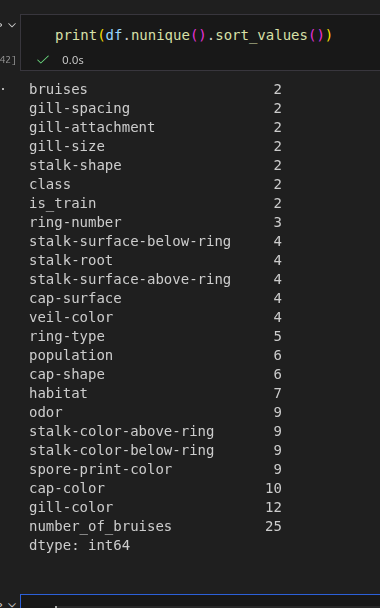

## Imputation

```python
imp.fit() returns the imputer machine itself, not the transformed data.
thus use .fit_transform() to get the transformed data after fitting the imputer machine.
```